<a href="https://colab.research.google.com/github/Chandhana-sanoj/ICT_DSA_2026/blob/main/Unsupervised_learning_casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Loading Data

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/ICT/adult_dataset.csv")

In [ ]:
len(data)

48842

In [ ]:
data.head(2)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [ ]:
data.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


# Data Preprocessing and EDA

## Handling duplicates

In [ ]:
data.duplicated().sum()

np.int64(16)

In [ ]:
data = data.drop_duplicates()

In [ ]:
data.duplicated().sum()

np.int64(0)

## Splitting Numerical and Categorical Columns

In [ ]:
num_cols = data.select_dtypes(include=['number']).columns
cat_cols = data.select_dtypes(include=['object']).columns

In [ ]:
num_cols

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [ ]:
cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

## Handling Missing Values

In [ ]:
data.isna().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [ ]:
missing_percentage = data.isna().sum() / len(data) * 100
missing_percentage = missing_percentage.sort_values(ascending=False)
missing_percentage

,0
workclass,6.885676
occupation,6.875435
native-country,5.540081
hours-per-week,5.001434
age,5.001434
fnlwgt,0.000000
education,0.000000
marital-status,0.000000
education-num,0.000000
relationship,0.000000


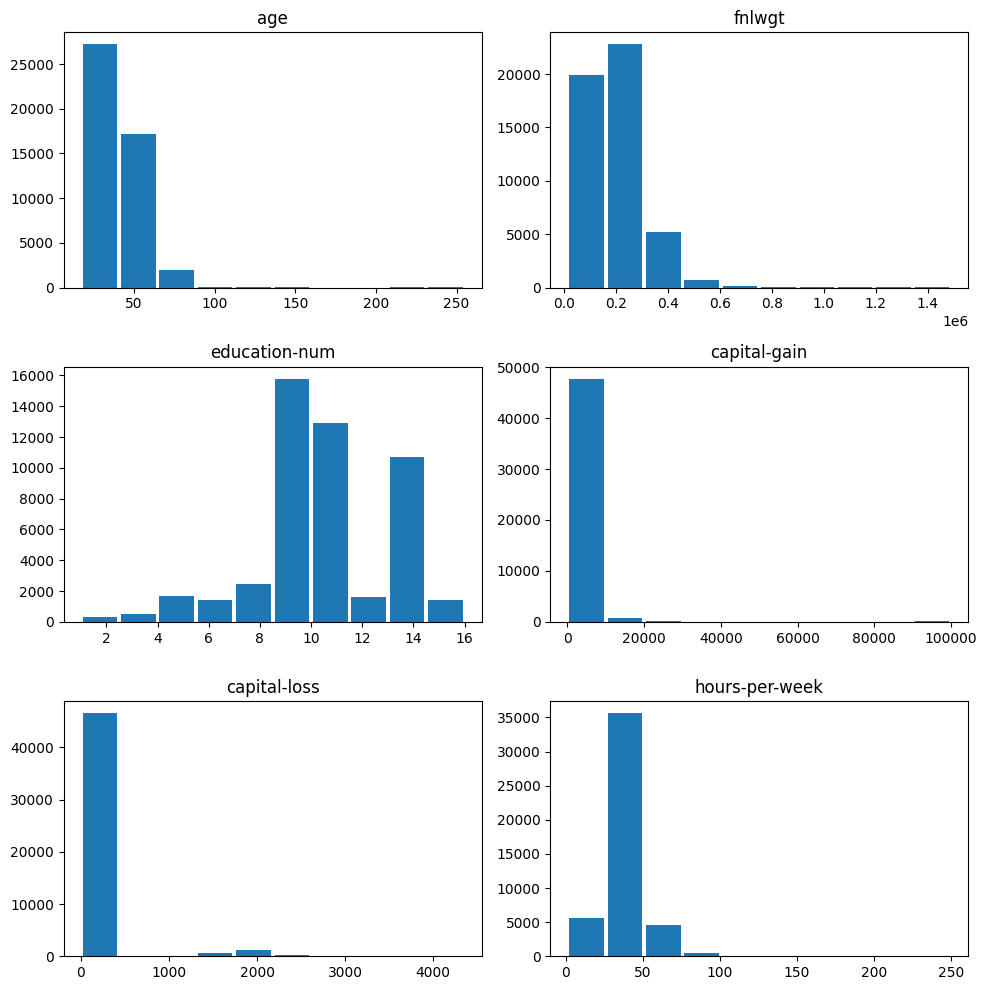

In [ ]:
plt.figure(figsize=(10, 10))
for i, col in enumerate(num_cols, 1):
  plt.subplot(3, 2, i)
  plt.hist(data[col], rwidth=0.9)
  plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
# Columns are skewed and hence null values are replaced using median

data = data.fillna(data[num_cols].median())

In [ ]:
data.isna().sum()

,0
age,0
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [ ]:
# null Values in numerical cols are removed.
# handling null values in categorical columns
# Using mode to replace null values

In [ ]:
data = data.fillna(data[cat_cols].mode().iloc[0])
# .iloc[0] grabs the first mode for each column and returns a Series

In [ ]:
data.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
data.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48826.000000,4.882600e+04,48826.000000,48826.000000,48826.000000,48826.000000
mean,38.597428,1.896605e+05,10.078278,1079.421230,87.530988,40.428481
std,13.602653,1.056025e+05,2.570759,7453.214369,403.067466,12.326046
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781385e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376170e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [ ]:
data.head(2)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K


In [ ]:
for col in cat_cols:
  print(data[col].value_counts())
  print()

workclass
Private             35567
Self-emp-not-inc     3649
Local-gov            2973
State-gov            1877
?                    1763
Self-emp-inc         1624
Federal-gov          1346
Without-pay            18
Never-worked            9
Name: count, dtype: int64

education
HS-grad         15780
Some-college    10874
Bachelors        8021
Masters          2657
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              656
Doctorate         594
5th-6th           508
1st-4th           246
Preschool          83
Name: count, dtype: int64

marital-status
Married-civ-spouse       22377
Never-married            16105
Divorced                  6631
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

occupation
Prof-specialty       9208
Craft-repair         5790
Exec-managerial   

In [ ]:
for col in cat_cols:
  print(data[col].value_counts(normalize=True) * 100)
  print()

workclass
Private             72.844386
Self-emp-not-inc     7.473477
Local-gov            6.088969
State-gov            3.844263
?                    3.610781
Self-emp-inc         3.326097
Federal-gov          2.756728
Without-pay          0.036866
Never-worked         0.018433
Name: proportion, dtype: float64

education
HS-grad         32.318847
Some-college    22.270921
Bachelors       16.427723
Masters          5.441773
Assoc-voc        4.219064
11th             3.711138
Assoc-acdm       3.278991
10th             2.844796
7th-8th          1.955925
Prof-school      1.708106
9th              1.548355
12th             1.343546
Doctorate        1.216565
5th-6th          1.040429
1st-4th          0.503830
Preschool        0.169991
Name: proportion, dtype: float64

marital-status
Married-civ-spouse       45.830091
Never-married            32.984475
Divorced                 13.580879
Separated                 3.133576
Widowed                   3.108999
Married-spouse-absent     1.286200
M

In [ ]:
# workclass, occupation and native country have '?' as entries which has to be handled
# since the % of '?' in these columns is pretty low, dropping the rows as it prevents mode bias
# along with minimal loss of statistical power

In [ ]:
data = data.replace('?', np.nan)
data.isna().sum()

,0
age,0
workclass,1763
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1758
relationship,0
race,0
sex,0


In [ ]:
data.dropna(inplace = True)

In [ ]:
data.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
for col in cat_cols:
  print(data[col].value_counts(normalize=True) * 100)
  print()

workclass
Private             75.559718
Self-emp-not-inc     7.777921
Local-gov            6.344183
State-gov            4.004133
Self-emp-inc         3.407819
Federal-gov          2.863171
Without-pay          0.038750
Never-worked         0.004306
Name: proportion, dtype: float64

education
HS-grad         32.560493
Some-college    22.100232
Bachelors       16.608542
Masters          5.519676
Assoc-voc        4.273228
11th             3.631706
Assoc-acdm       3.319556
10th             2.746922
7th-8th          1.864290
Prof-school      1.724361
9th              1.500474
12th             1.291656
Doctorate        1.203393
5th-6th          0.996728
1st-4th          0.492982
Preschool        0.165763
Name: proportion, dtype: float64

marital-status
Married-civ-spouse       46.239129
Never-married            32.625075
Divorced                 13.790580
Separated                 3.108585
Widowed                   2.910531
Married-spouse-absent     1.250753
Married-AF-spouse         0.075

## Handling Outliers

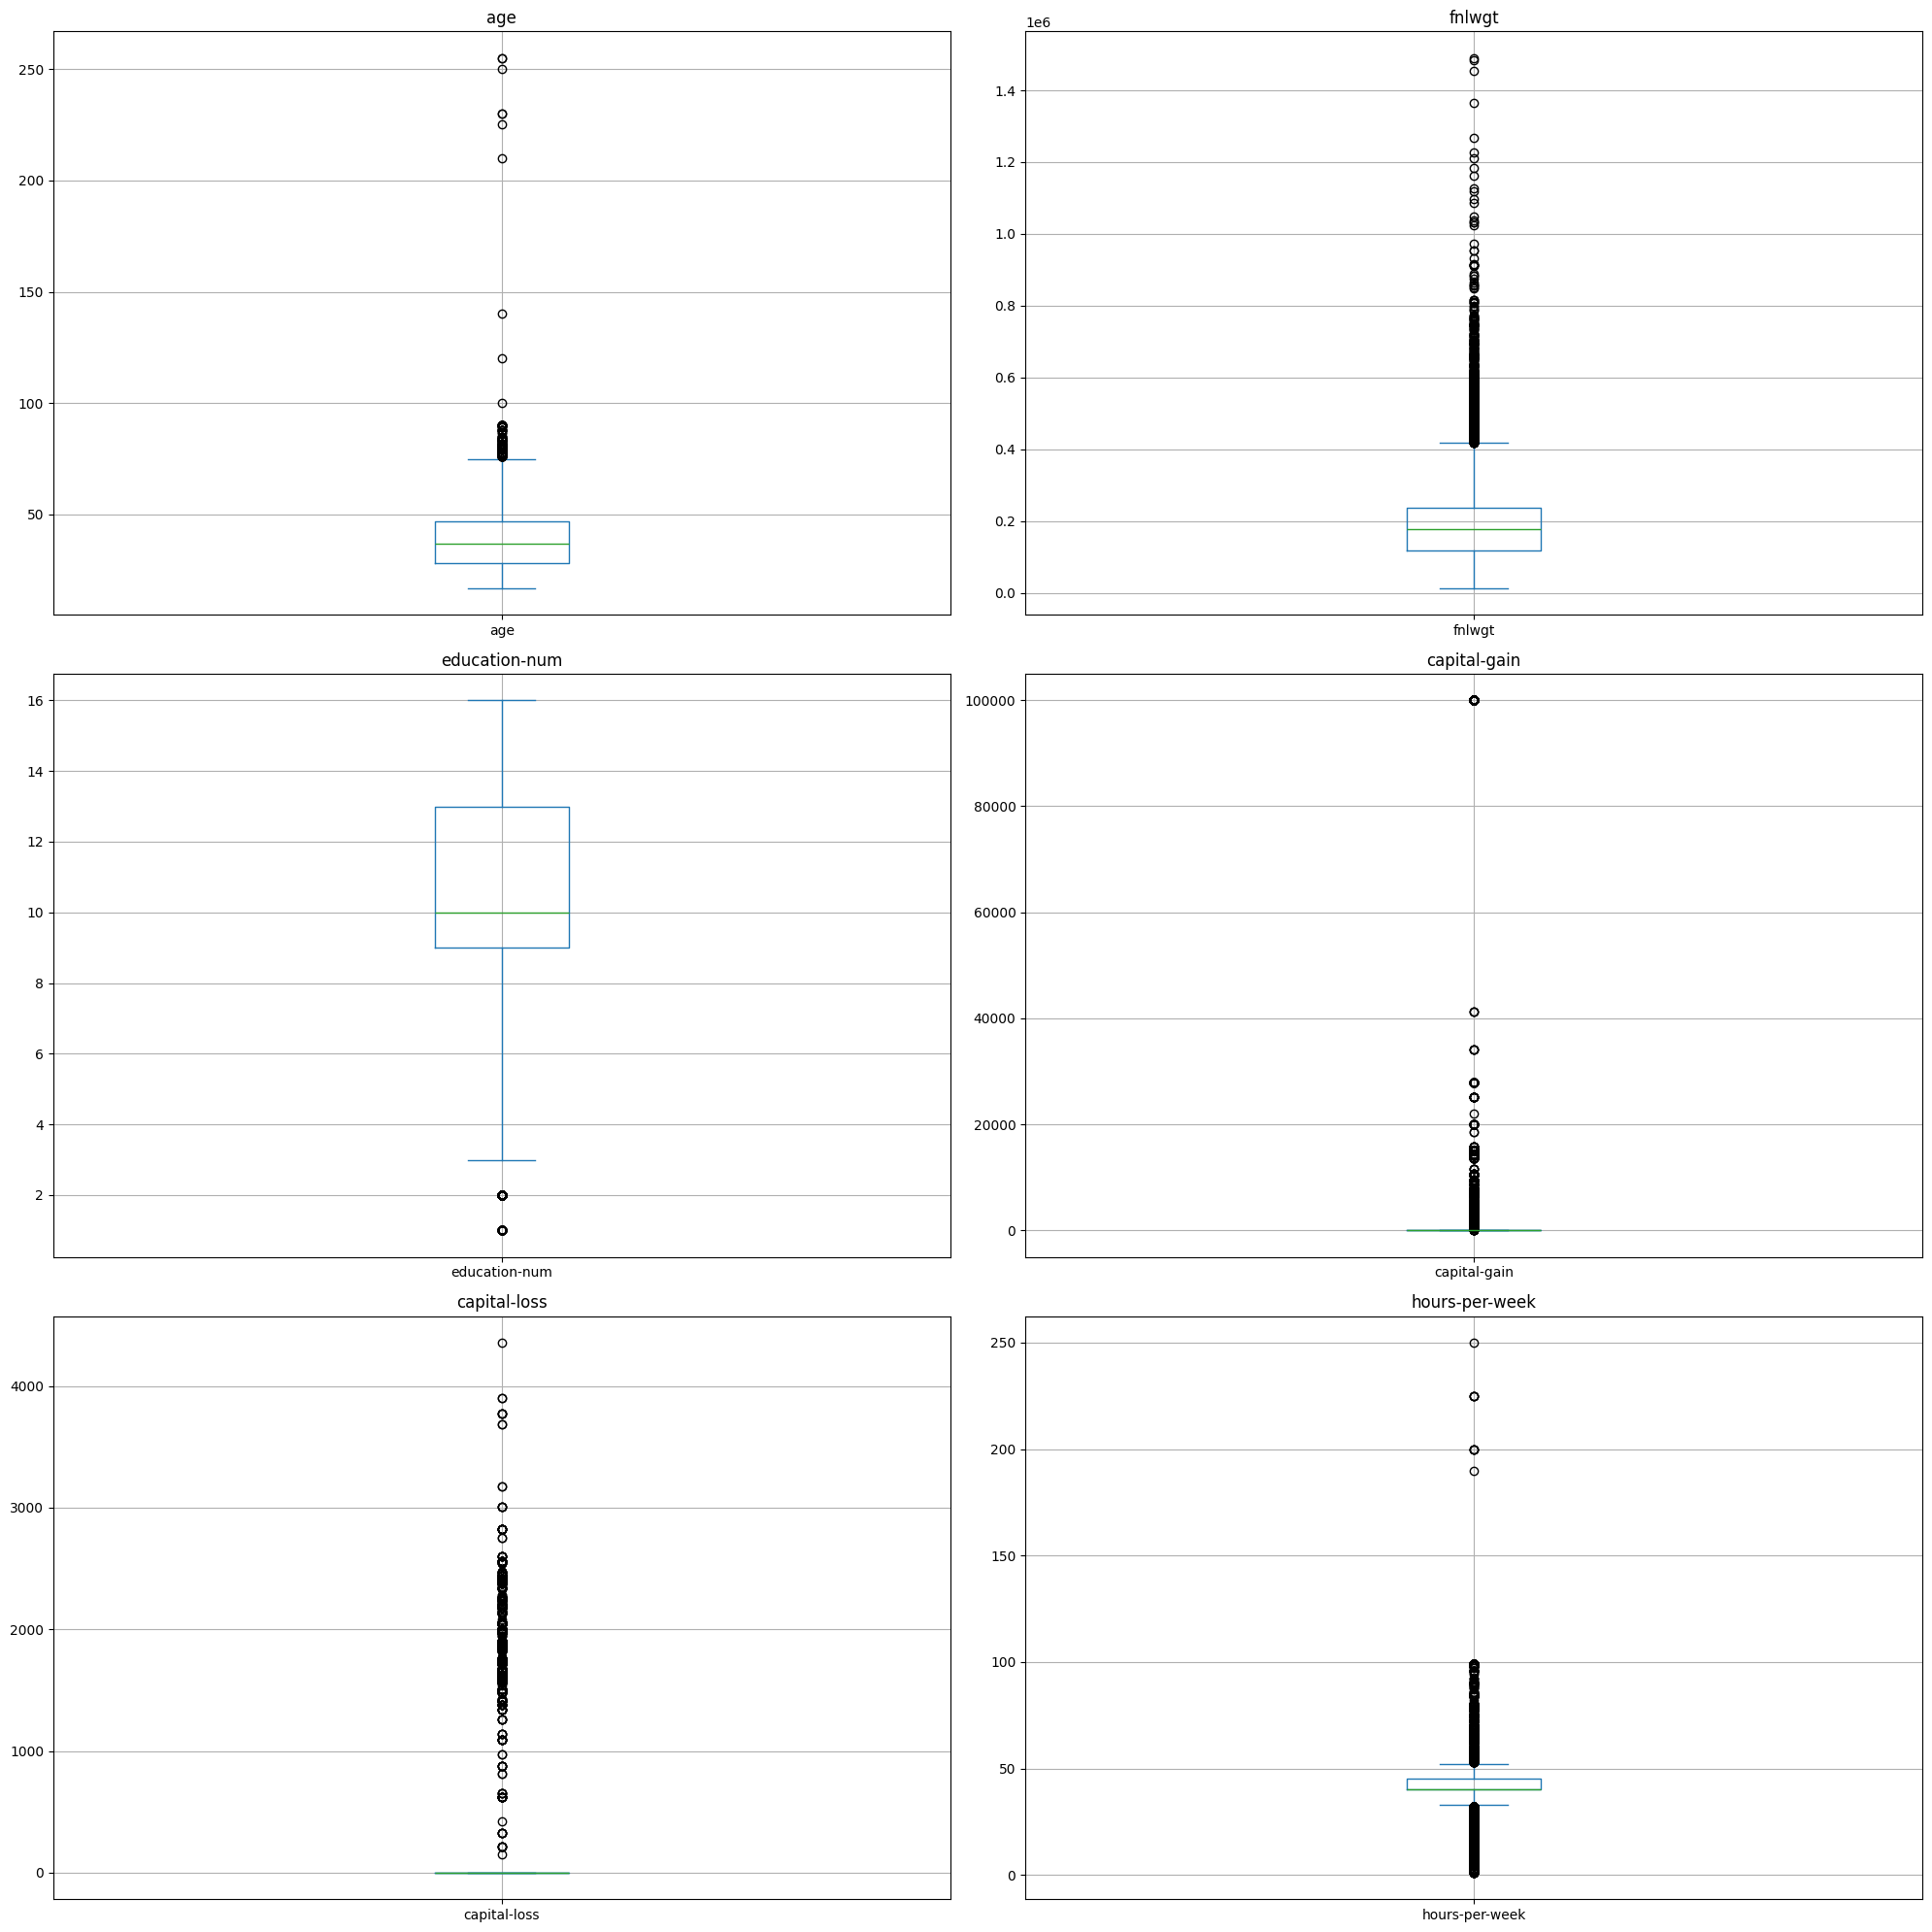

In [ ]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(num_cols, 1):
  ax = plt.subplot(3, 2, i)
  data[col].plot(kind = 'box', ax = ax)
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
Q1 = data[num_cols].quantile(0.25)
Q3 = data[num_cols].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + (1.5 * IQR)
lower_limit = Q1 - (1.5 * IQR)

outliers = ((data[num_cols] > upper_limit) | (data[num_cols] < lower_limit)).any(axis = 1)
outliers_df = data[outliers]

outlier_percent = len(outliers_df) / len(data) * 100
print("percentage fo outliers in the dataframe :", outlier_percent)

percentage fo outliers in the dataframe : 37.9574614655989


In [ ]:
outlier_counts = ((data[num_cols] > upper_limit) |
                  (data[num_cols] < lower_limit)).mean()*100

print(outlier_counts.sort_values(ascending=False))

hours-per-week    25.482218
capital-gain       8.318264
capital-loss       4.718850
fnlwgt             2.962198
education-num      0.658745
age                0.635064
dtype: float64


In [ ]:
# clipping columns age, fnlwgt and education-num since these have very few outliers
cols_to_cap = ['age', 'fnlwgt', 'education-num']
data[cols_to_cap] = data[cols_to_cap].clip(lower_limit, upper_limit, axis=1)

In [ ]:
# Applying log transform to capital-gain and capital-loss
# Not ideal to cap these because the difference between a $50,000 gain and a $99,000 gain actually matters for clustering rich people.
# A Log Transform mathematically shrinks the massive gap between $0 and $99,000 turning an exponential curve into a smooth curve.
cols_to_log = ['capital-gain', 'capital-loss']

for col in cols_to_log:
    data[col] = np.log1p(data[col])

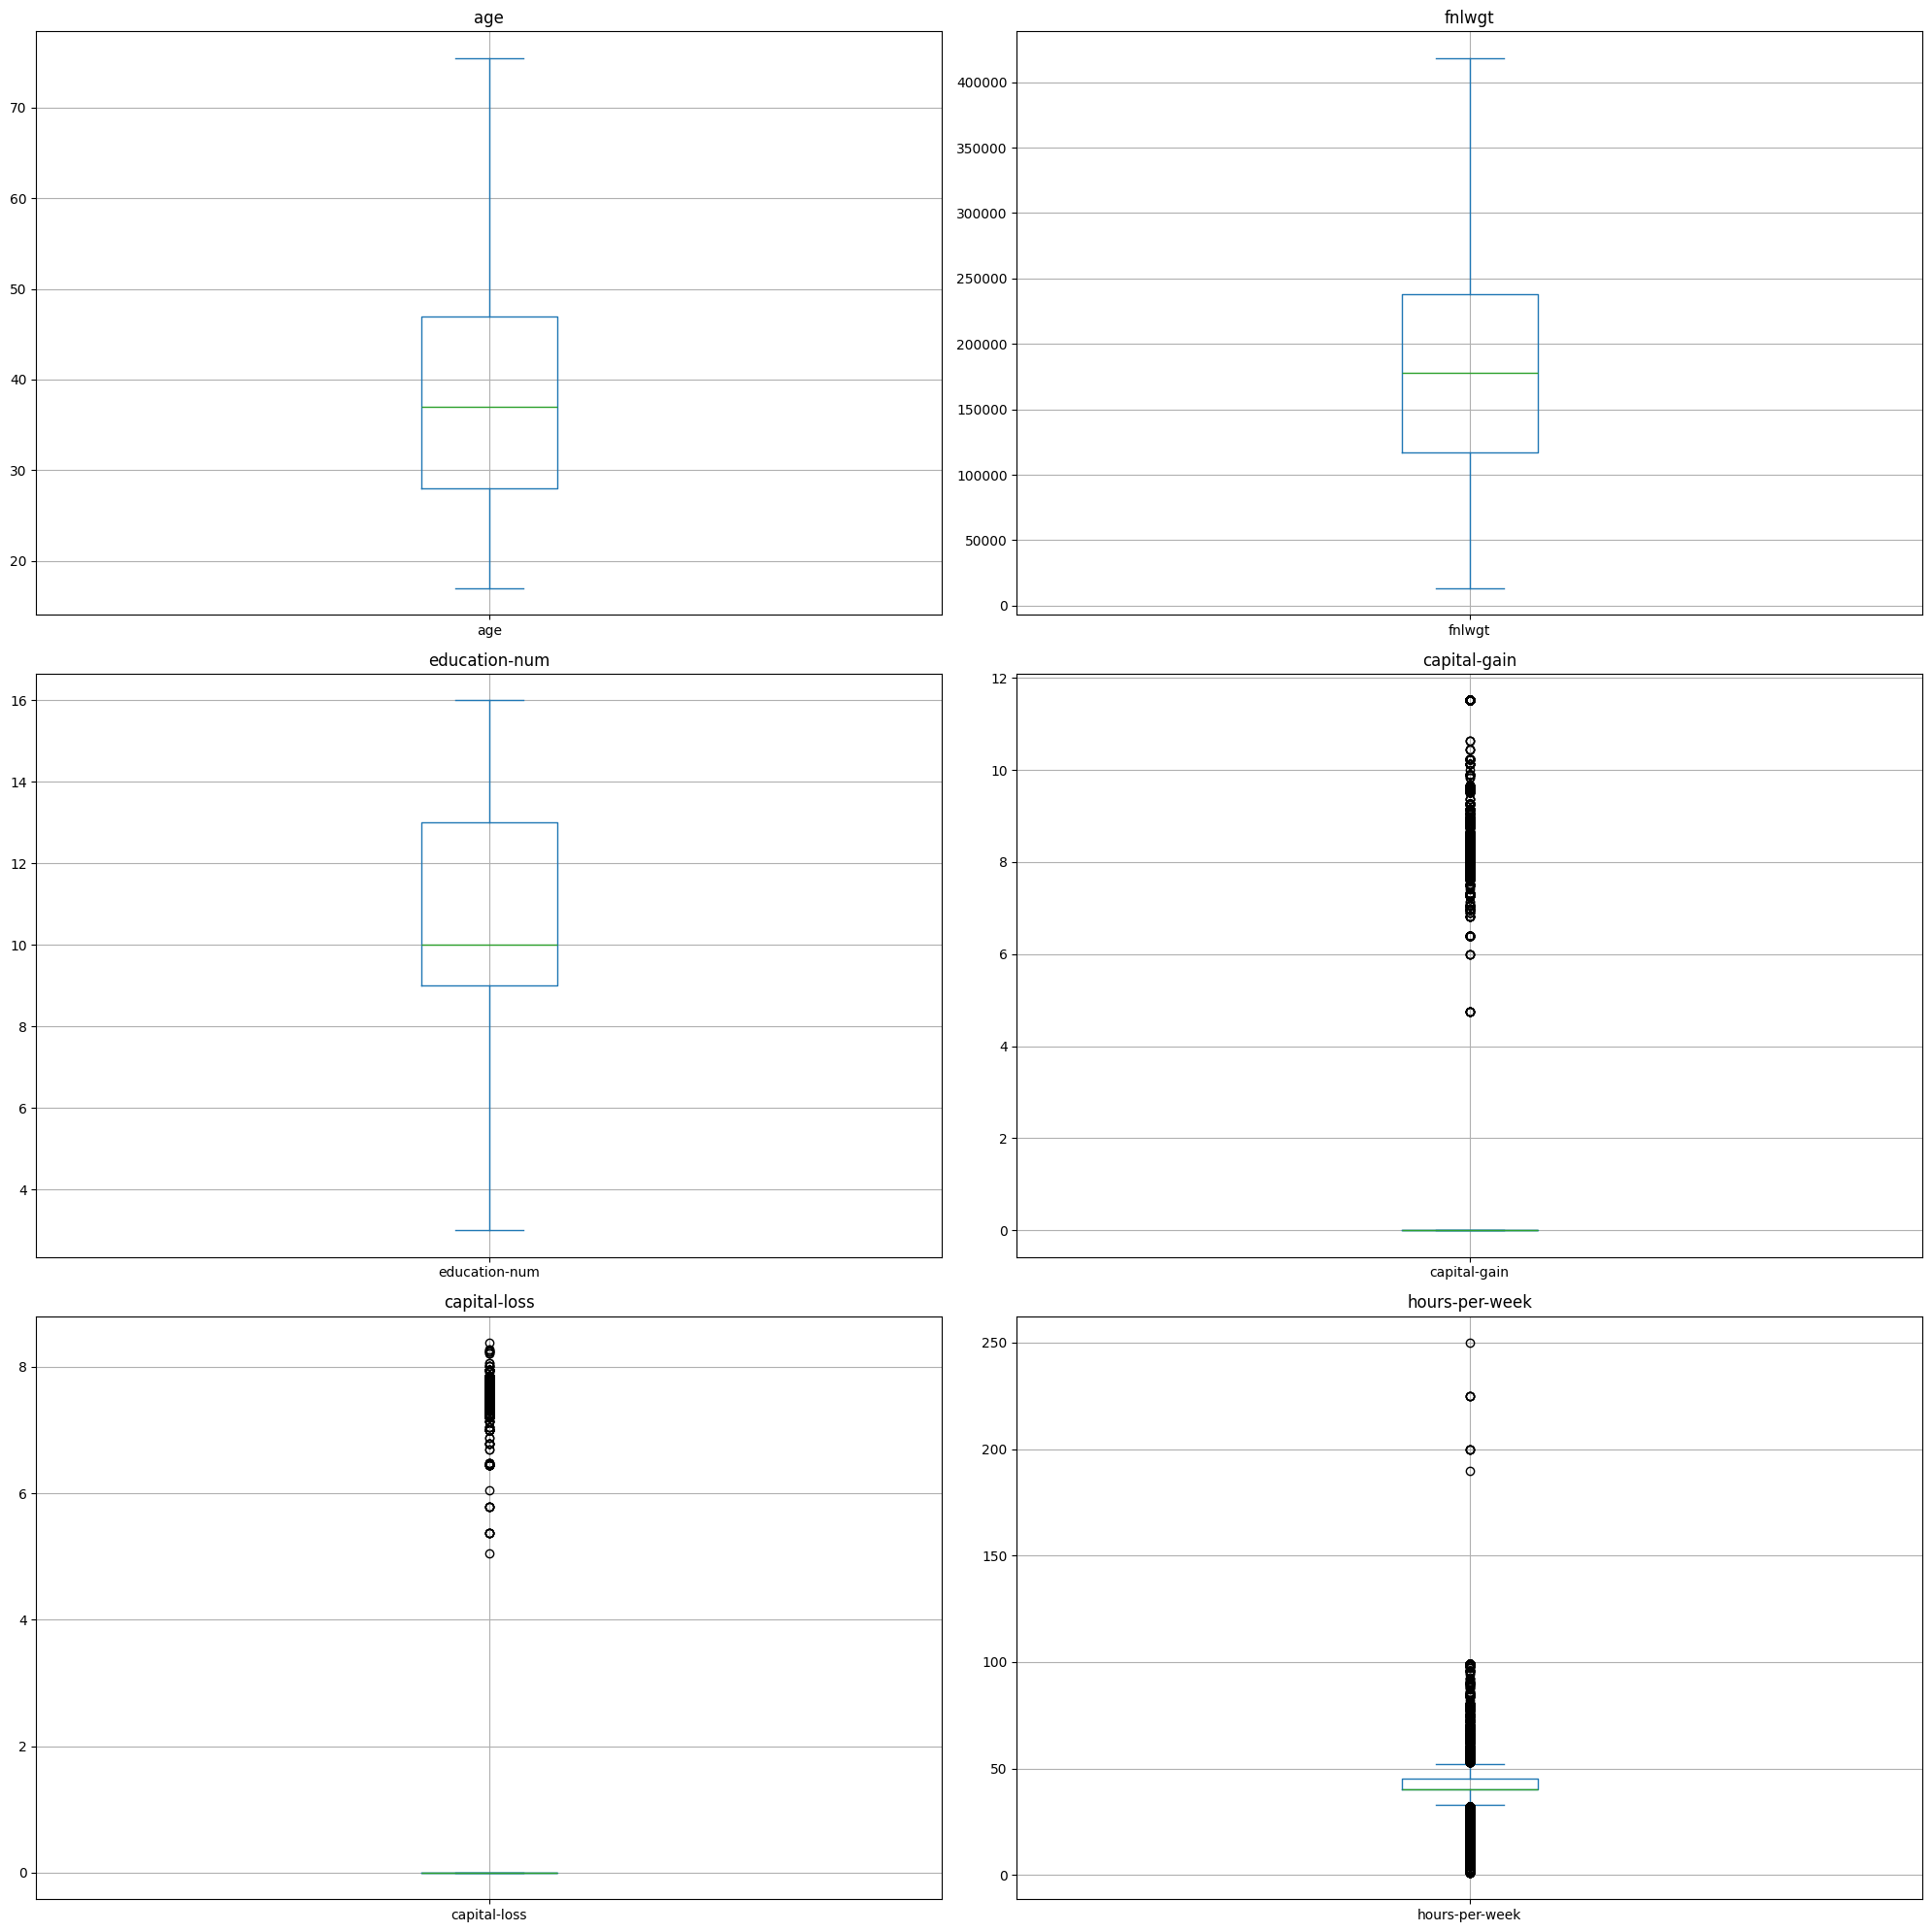

In [ ]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(num_cols, 1):
  ax = plt.subplot(3, 2, i)
  data[col].plot(kind = 'box', ax = ax)
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
# Since 250 workhour a week is not possible, capping values where it exceeds '100'
data['hours-per-week'] = np.where(data['hours-per-week'] > 100, np.nan, data['hours-per-week'])

In [ ]:
data.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
data.dropna(inplace = True)

In [ ]:
data.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


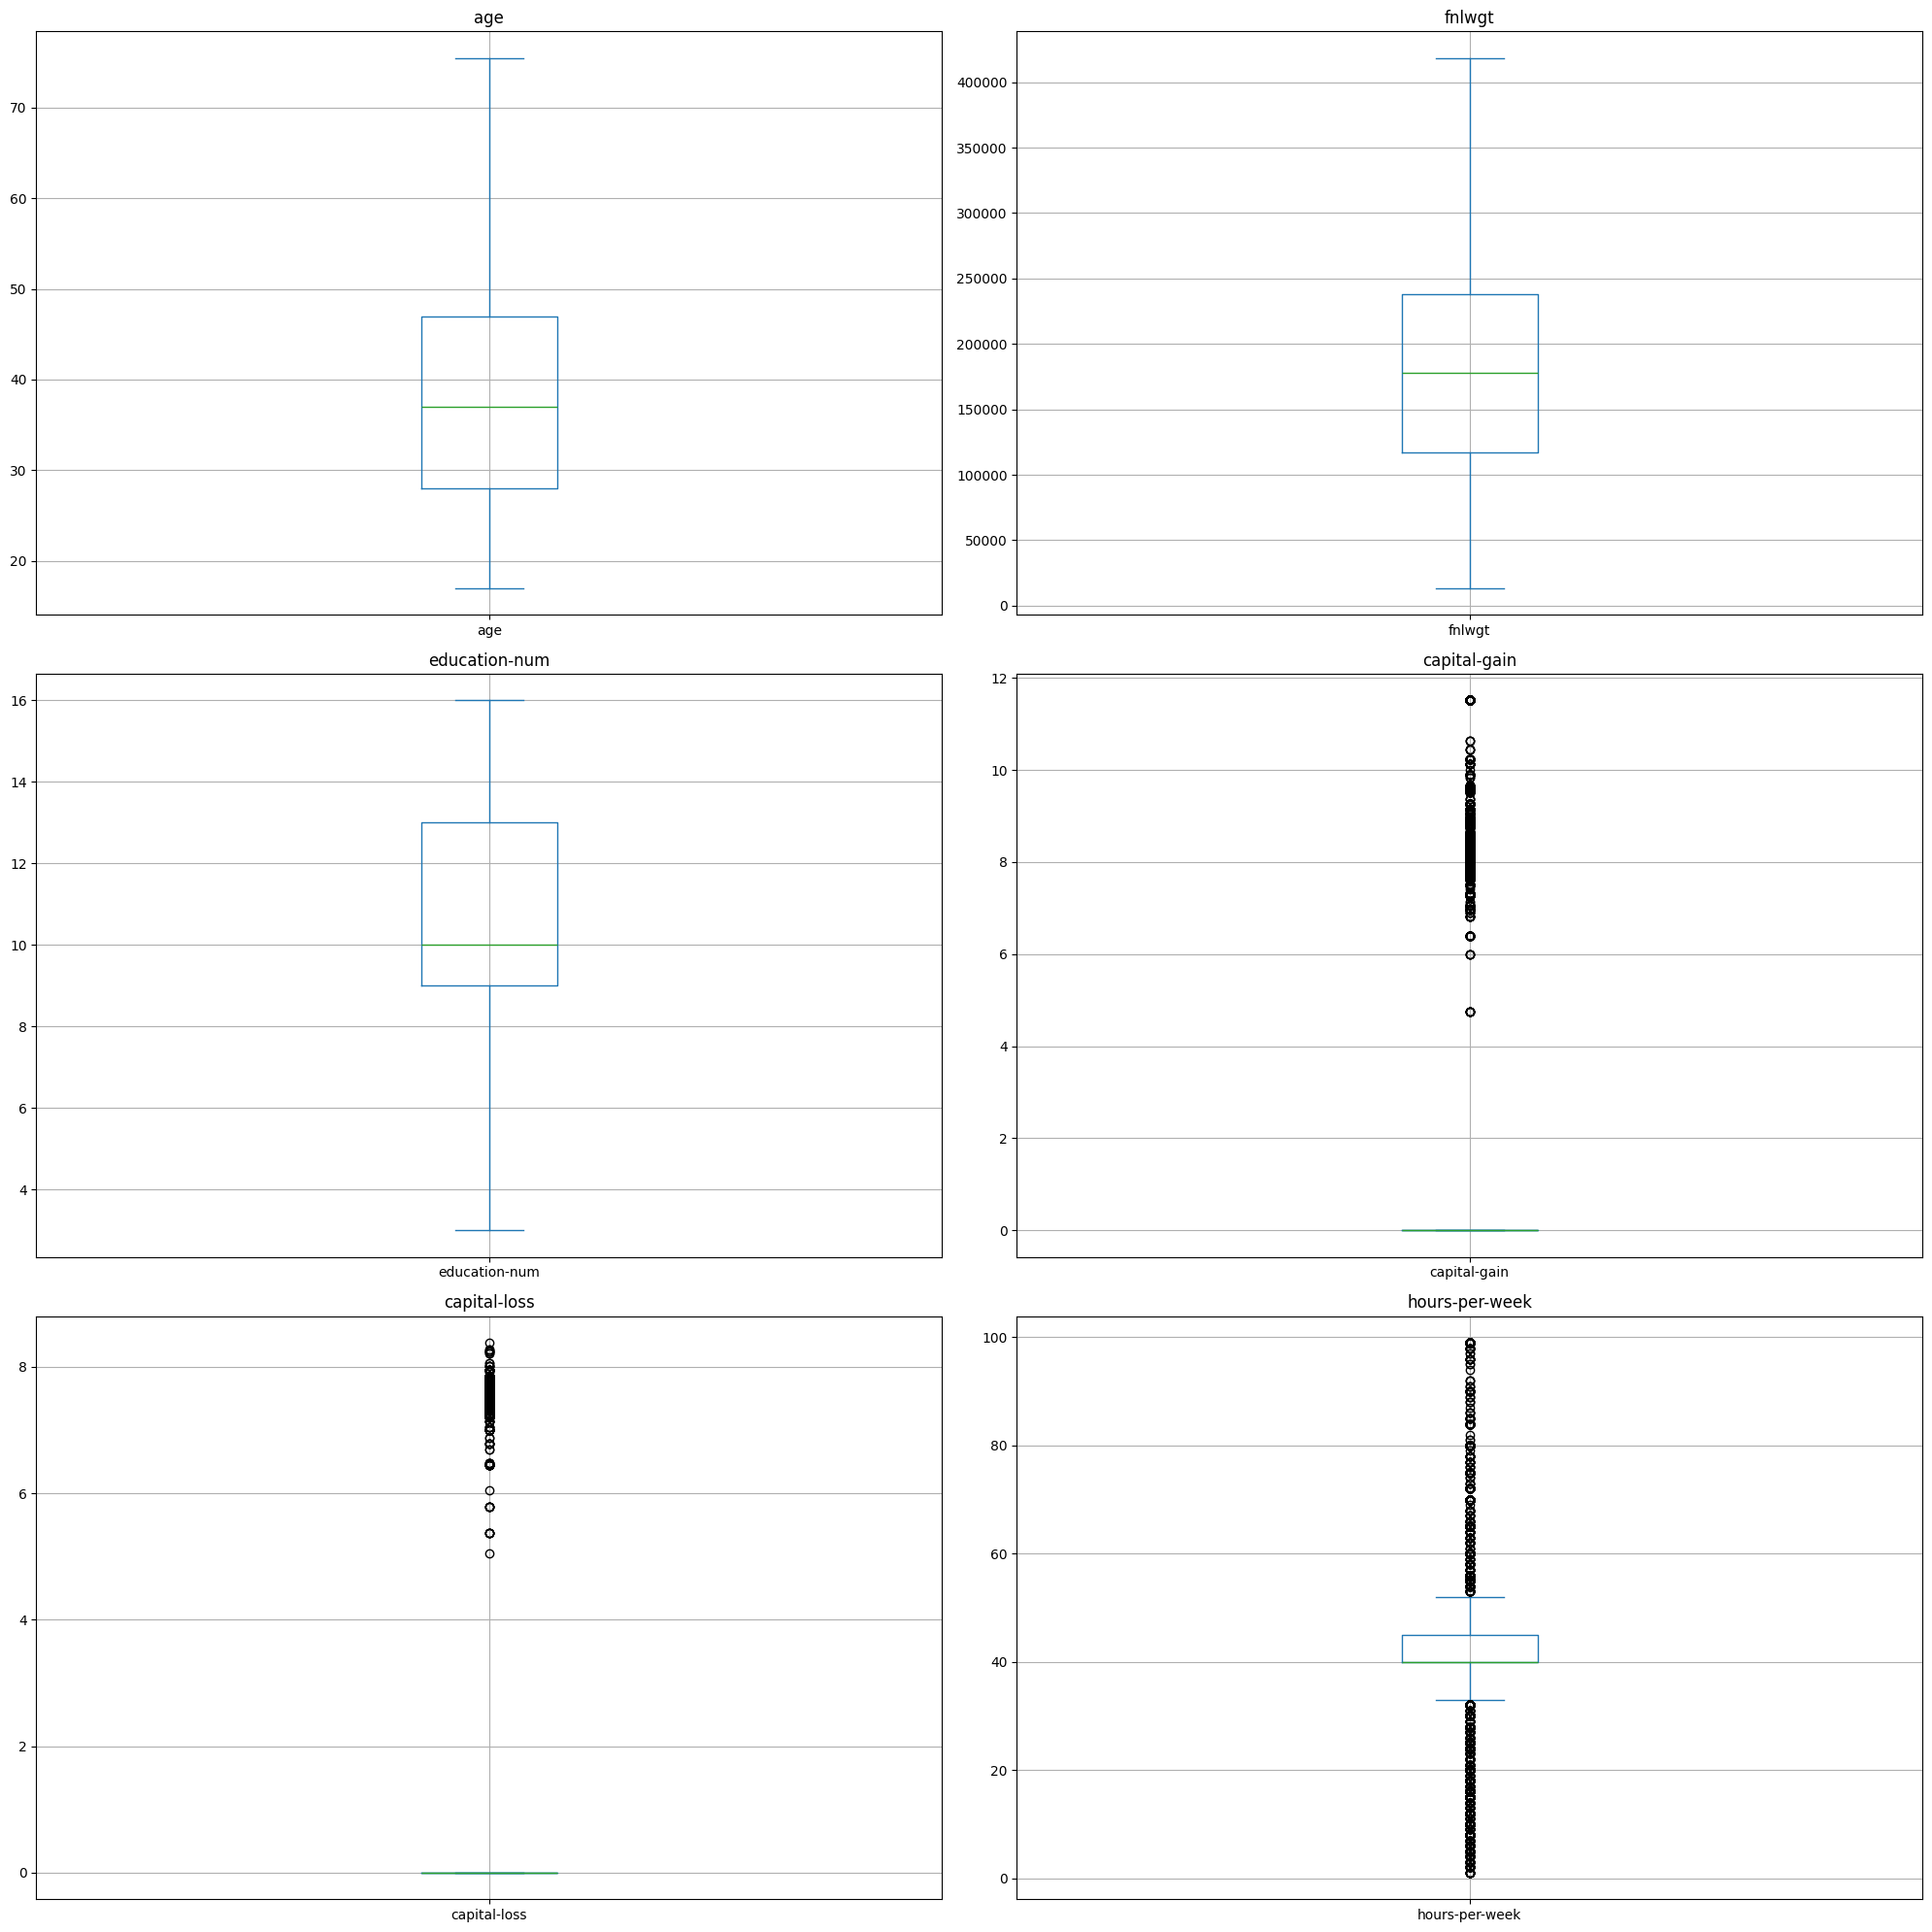

In [ ]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(num_cols, 1):
  ax = plt.subplot(3, 2, i)
  data[col].plot(kind = 'box', ax = ax)
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

## Removing Unwanted Columns

In [ ]:
corr_matrix = data[num_cols].corr(method='pearson')
corr_matrix

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.077015,0.036953,0.120115,0.053903,0.088337
fnlwgt,-0.077015,1.000000,-0.038430,-0.007991,-0.001850,-0.013998
education-num,0.036953,-0.038430,1.000000,0.130609,0.078761,0.143096
capital-gain,0.120115,-0.007991,0.130609,1.000000,-0.066522,0.085643
capital-loss,0.053903,-0.001850,0.078761,-0.066522,1.000000,0.047186
hours-per-week,0.088337,-0.013998,0.143096,0.085643,0.047186,1.000000


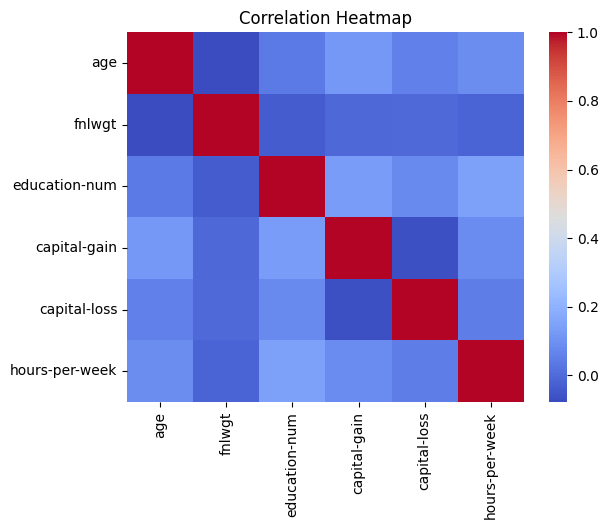

In [ ]:
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# dropping fnlwgt as it have low correlation
data.drop('fnlwgt', axis = 1, inplace = True)

In [ ]:
num_cols = num_cols.drop('fnlwgt')

In [ ]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')

In [ ]:
data[cat_cols].nunique()

,0
workclass,8
education,16
marital-status,7
occupation,14
relationship,6
race,5
sex,2
native-country,41
income,4


In [ ]:
# education and education_nums are essentially same, hence education is removed
data.drop('education', axis = 1, inplace=True)

In [ ]:
cat_cols = cat_cols.drop('education')

In [ ]:
data.drop('income', axis = 1, inplace = True)
cat_cols = cat_cols.drop('income')

## Scaling

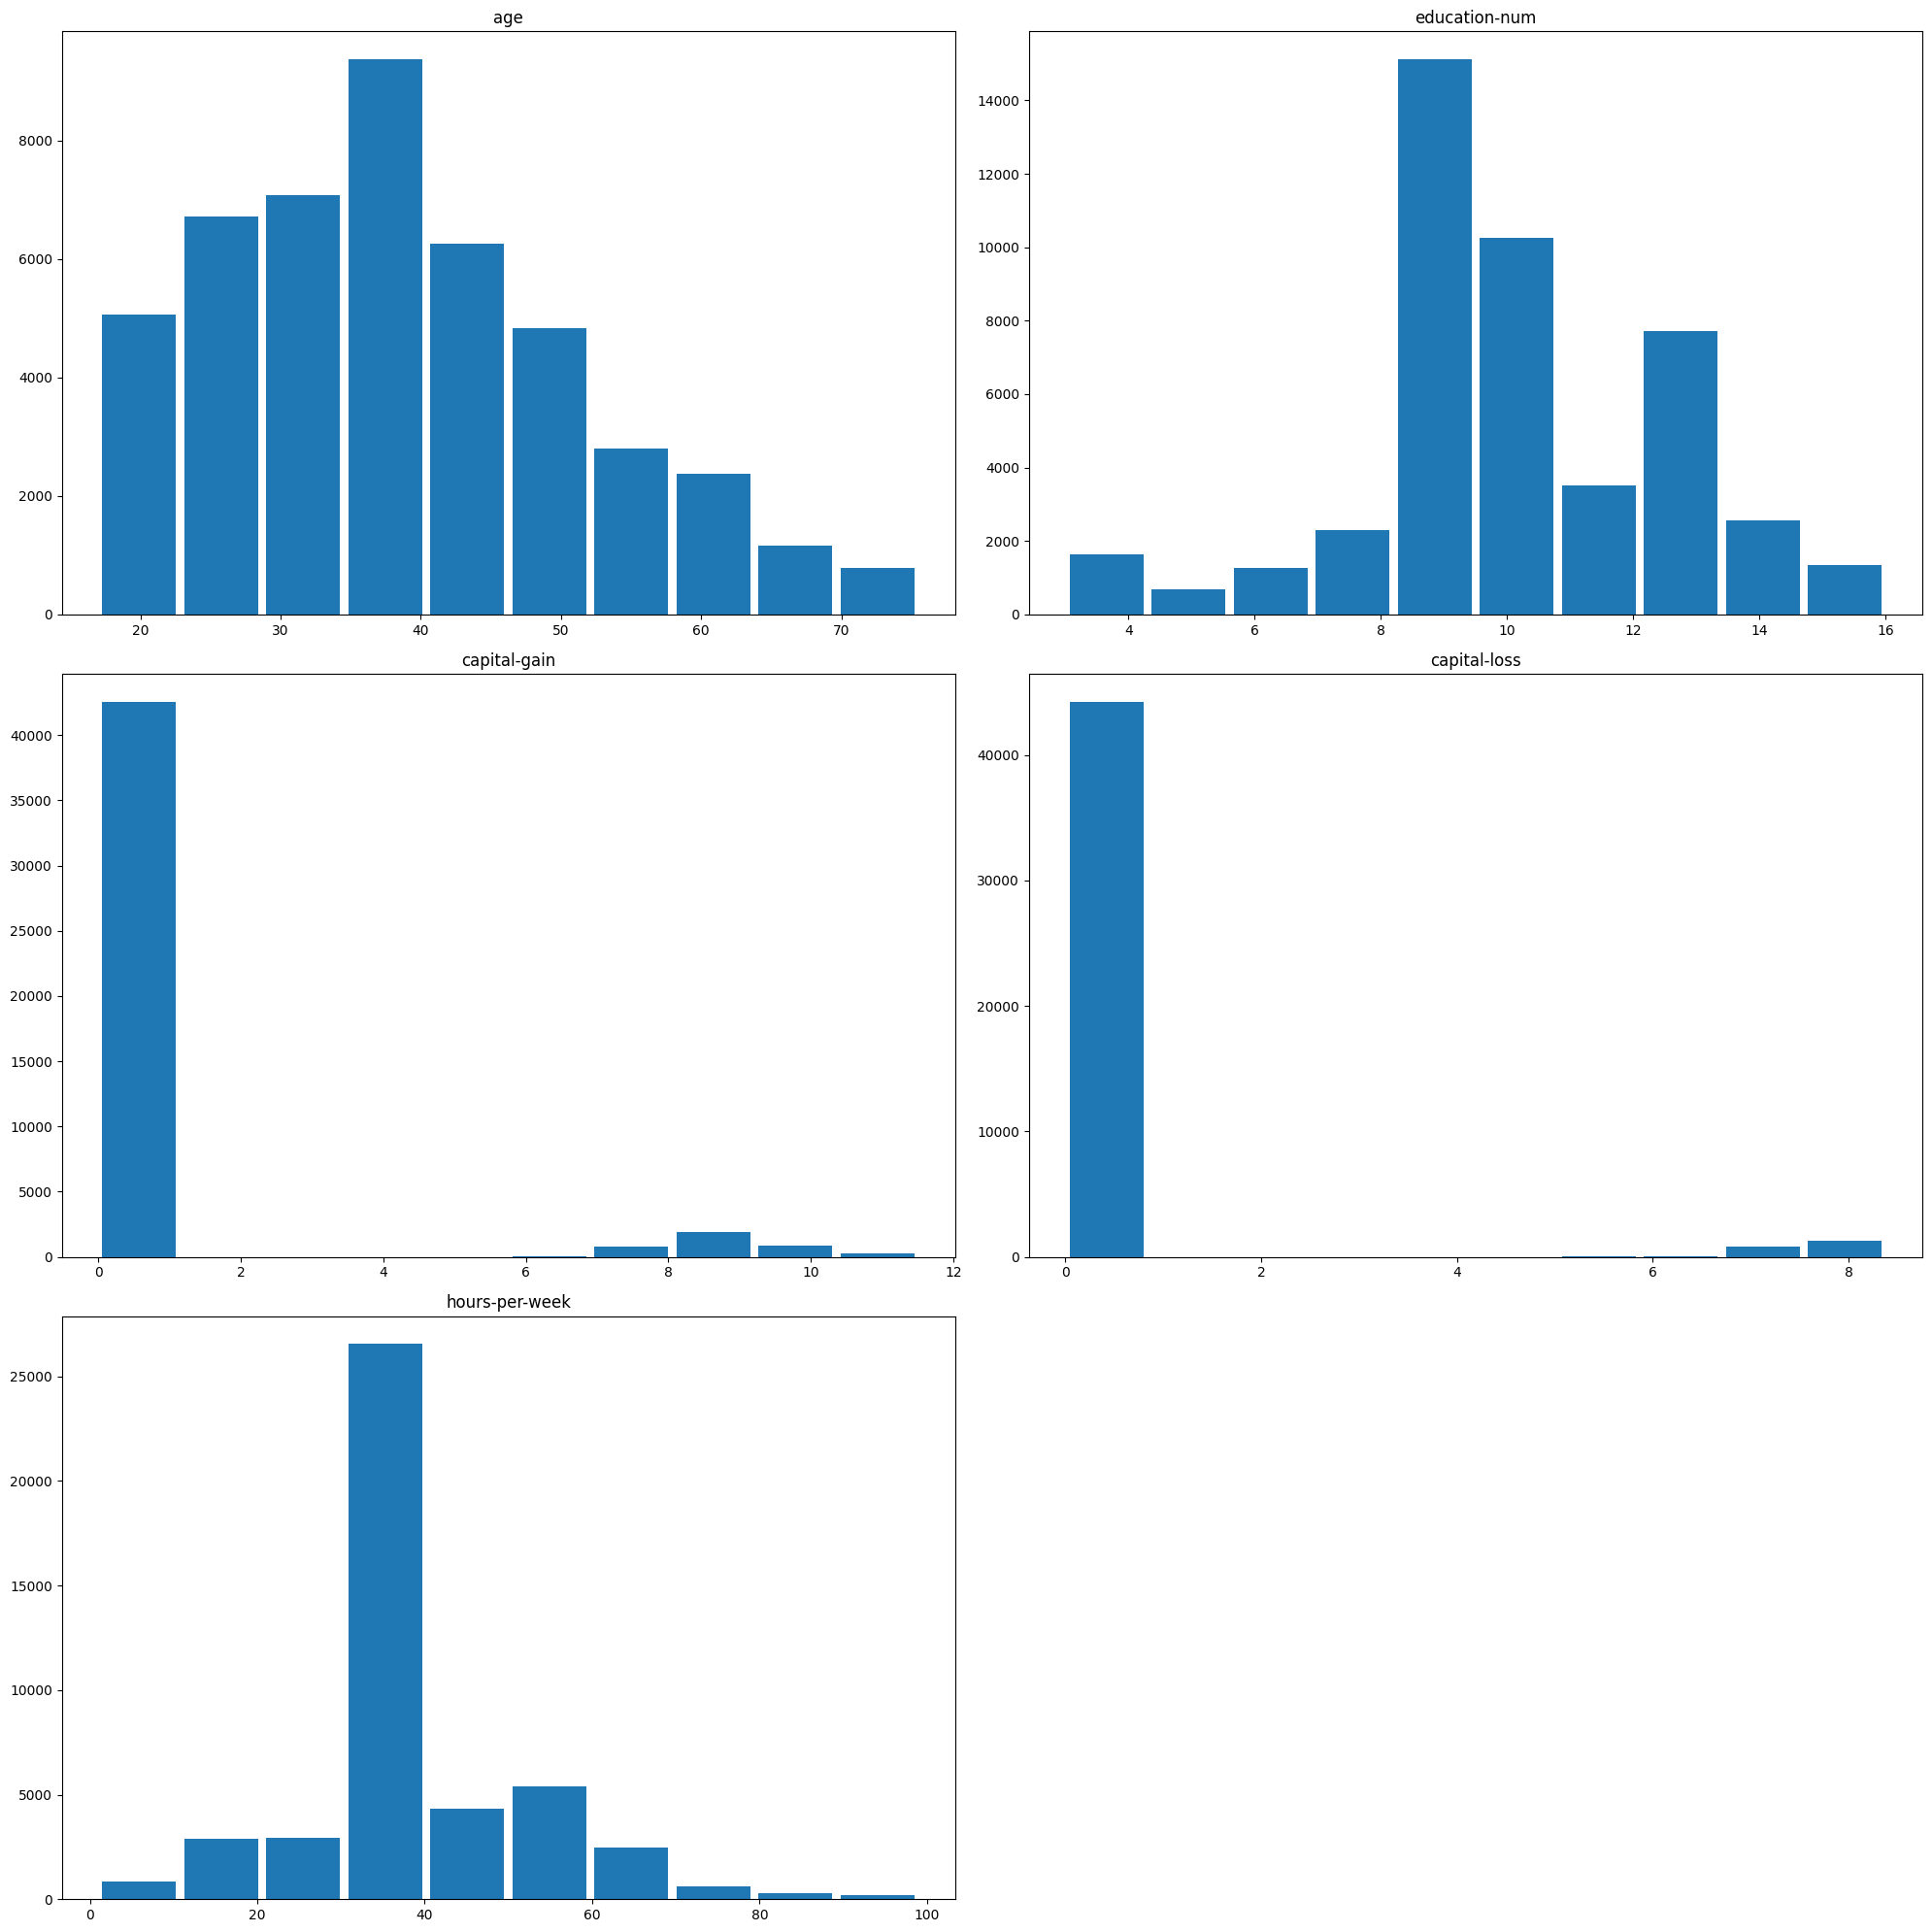

In [ ]:
plt.figure(figsize = (20, 20))
for i, col in enumerate(num_cols, 1):
  plt.subplot(3, 2, i)
  plt.hist(data[col], rwidth = 0.9)
  plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
# Before scaling
data.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,46442.000000,46442.000000,46442.000000,46442.000000,46442.000000
mean,38.447795,10.113669,0.734704,0.354362,40.692993
std,12.962627,2.530931,2.456286,1.593407,11.843214
min,17.000000,3.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000
max,75.500000,16.000000,11.512925,8.379539,99.000000


In [ ]:
scaler = StandardScaler()

data[num_cols] = scaler.fit_transform(data[num_cols])

In [ ]:
# after scaling
data.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,4.644200e+04,4.644200e+04,4.644200e+04,4.644200e+04,4.644200e+04
mean,-2.695785e-16,2.977297e-16,-3.977889e-18,2.968117e-17,7.037803e-17
std,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00
min,-1.654605e+00,-2.810723e+00,-2.991150e-01,-2.223953e-01,-3.351575e+00
25%,-8.060023e-01,-4.400281e-01,-2.991150e-01,-2.223953e-01,-5.851459e-02
50%,-1.116911e-01,-4.491229e-02,-2.991150e-01,-2.223953e-01,-5.851459e-02
75%,6.597657e-01,1.140435e+00,-2.991150e-01,-2.223953e-01,3.636726e-01
max,2.858418e+00,2.325783e+00,4.388063e+00,5.036544e+00,4.923295e+00


In [ ]:
# education and education-num are essentially the same

## Grouping values inside cat_cols

In [ ]:
data['native-country'].value_counts()

,count
native-country,
United-States,42627
Mexico,876
Philippines,273
Germany,185
Puerto-Rico,169
Canada,157
India,143
El-Salvador,142
Cuba,129


In [ ]:
# High-dimensional noise from 40+ binary columns would and degrade clustering performance

In [ ]:
data['native-country'] = data['native-country'].str.strip()

In [ ]:
data['native-country'] = np.where(data['native-country'] == 'United-States', 'United-States', 'Other')

In [ ]:
data[cat_cols].nunique()

,0
workclass,8
marital-status,7
occupation,14
relationship,6
race,5
sex,2
native-country,2


In [ ]:
# Grouping Marital status into two to keep dimensions low
data['marital-status'] = data['marital-status'].replace(['Married-civ-spouse','Married-spouse-absent','Married-AF-spouse'], 'Married')
data['marital-status'] = data['marital-status'].replace(['Never-married','Divorced','Separated','Widowed'], 'Single')

In [ ]:
data['workclass'].value_counts()

,count
workclass,
Private,35089
Self-emp-not-inc,3613
Local-gov,2947
State-gov,1860
Self-emp-inc,1583
Federal-gov,1330
Without-pay,18
Never-worked,2


In [ ]:
data['workclass'] = data['workclass'].str.strip()

workclass_map = {
    'Local-gov': 'Government',
    'State-gov': 'Government',
    'Federal-gov': 'Government',
    'Self-emp-not-inc': 'Self-Employed',
    'Self-emp-inc': 'Self-Employed',
    'Without-pay': 'Other',
    'Never-worked': 'Other'
}

# Apply the mapping
data['workclass'] = data['workclass'].replace(workclass_map)

print(data['workclass'].value_counts())

workclass
Private          35089
Government        6137
Self-Employed     5196
Other               20
Name: count, dtype: int64


## Encoding

In [ ]:
for i, col in enumerate(cat_cols, 1):
  print(data[col].unique())

['Government' 'Self-Employed' 'Private' 'Other']
['Single' 'Married']
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Transport-moving' 'Farming-fishing'
 'Machine-op-inspct' 'Tech-support' 'Craft-repair' 'Protective-serv'
 'Armed-Forces' 'Priv-house-serv']
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']
['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']
['Male' 'Female']
['United-States' 'Other']


In [ ]:
data = pd.get_dummies(data[cat_cols], drop_first=True, dtype=int)

In [ ]:
data.head(3)

,workclass_Other,workclass_Private,workclass_Self-Employed,marital-status_Single,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,...,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male,native-country_United-States
0,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,1
1,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,1,1
2,0,1,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,1,1


In [ ]:
data.columns

Index(['workclass_Other', 'workclass_Private', 'workclass_Self-Employed',
       'marital-status_Single', 'occupation_Armed-Forces',
       'occupation_Craft-repair', 'occupation_Exec-managerial',
       'occupation_Farming-fishing', 'occupation_Handlers-cleaners',
       'occupation_Machine-op-inspct', 'occupation_Other-service',
       'occupation_Priv-house-serv', 'occupation_Prof-specialty',
       'occupation_Protective-serv', 'occupation_Sales',
       'occupation_Tech-support', 'occupation_Transport-moving',
       'relationship_Not-in-family', 'relationship_Other-relative',
       'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife',
       'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White',
       'sex_Male', 'native-country_United-States'],
      dtype='object')

# Dimensionality Reduction

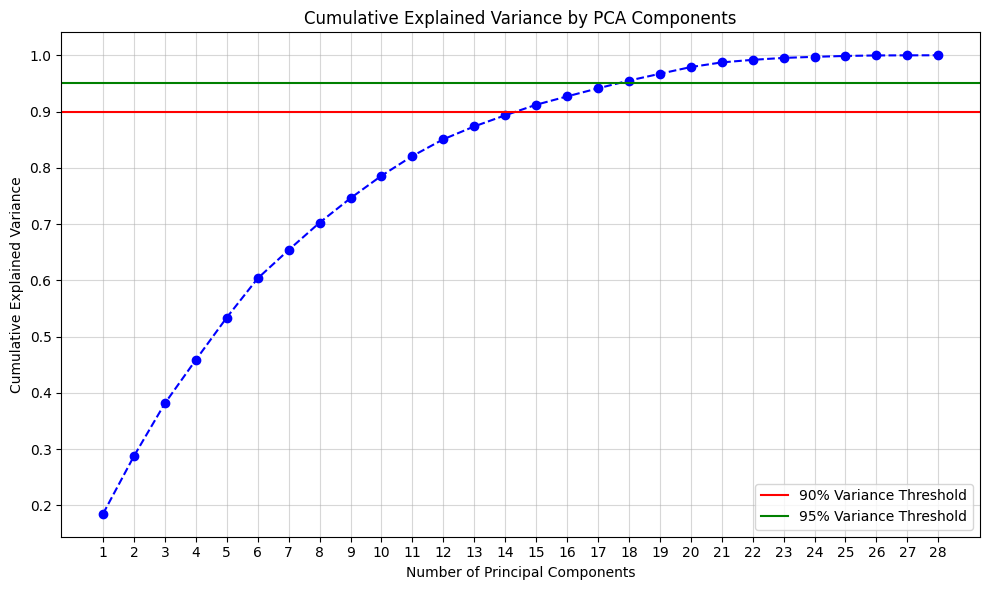

Original feature count: 28
Reduced feature count (95% variance): 18

First 5 rows of the PCA DataFrame:
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  0.278294 -0.829860  0.580450 -0.293155 -0.195941  0.105383  0.003046   
1 -0.991967 -0.862526 -0.209076 -0.097349 -0.499392 -0.362495 -0.506664   
2  0.459531 -0.045341  0.876181 -0.240891  0.015146  0.067016 -0.091685   
3 -0.405655  0.557065 -0.471637 -1.025241  0.418979  0.143501 -0.248443   
4  0.061885  0.245464 -1.220909 -0.278712  1.347697  0.042431 -0.125714   

        PC8       PC9      PC10      PC11      PC12      PC13      PC14  \
0 -0.000675  0.015219  0.148903  0.117360  0.187383 -0.207849 -0.432802   
1 -0.381236  0.094719 -0.112158 -0.059164 -0.137025  0.191476  0.244348   
2 -0.010825  0.097247  0.162652  0.084668  0.218538 -0.332566 -0.027124   
3  0.122929  0.000761 -0.093220  0.360218  0.150084 -0.283967  0.029706   
4  0.238871 -0.509625 -0.351461 -0.541739 -0.018911 -0.029109  0.18907

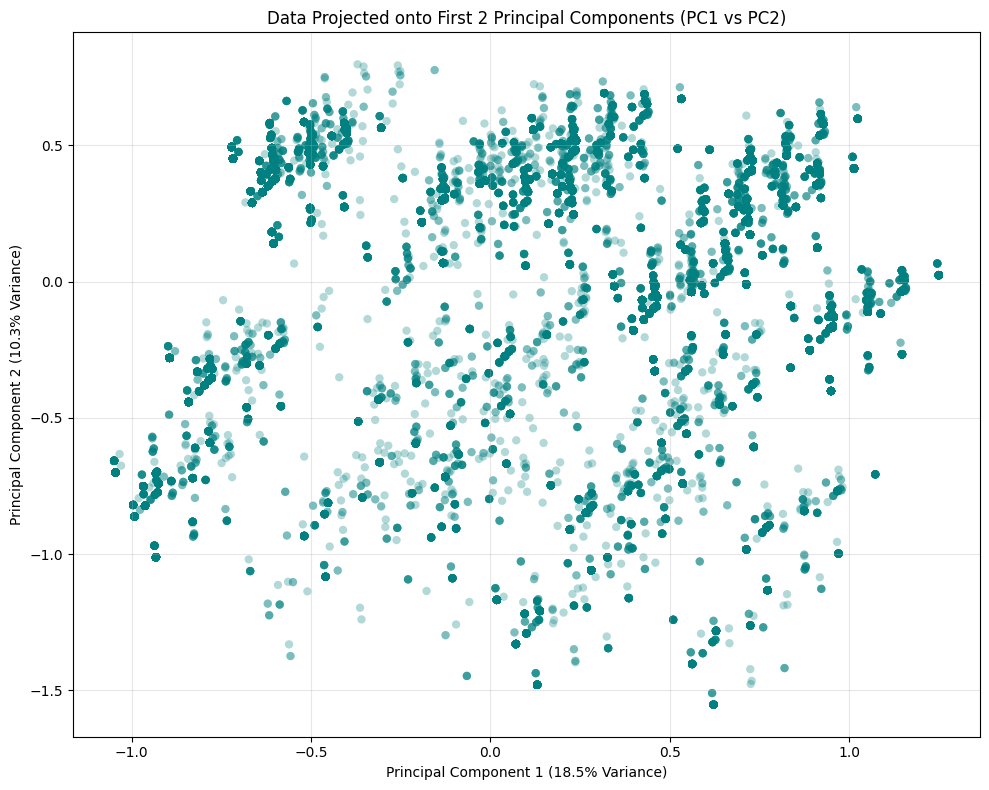

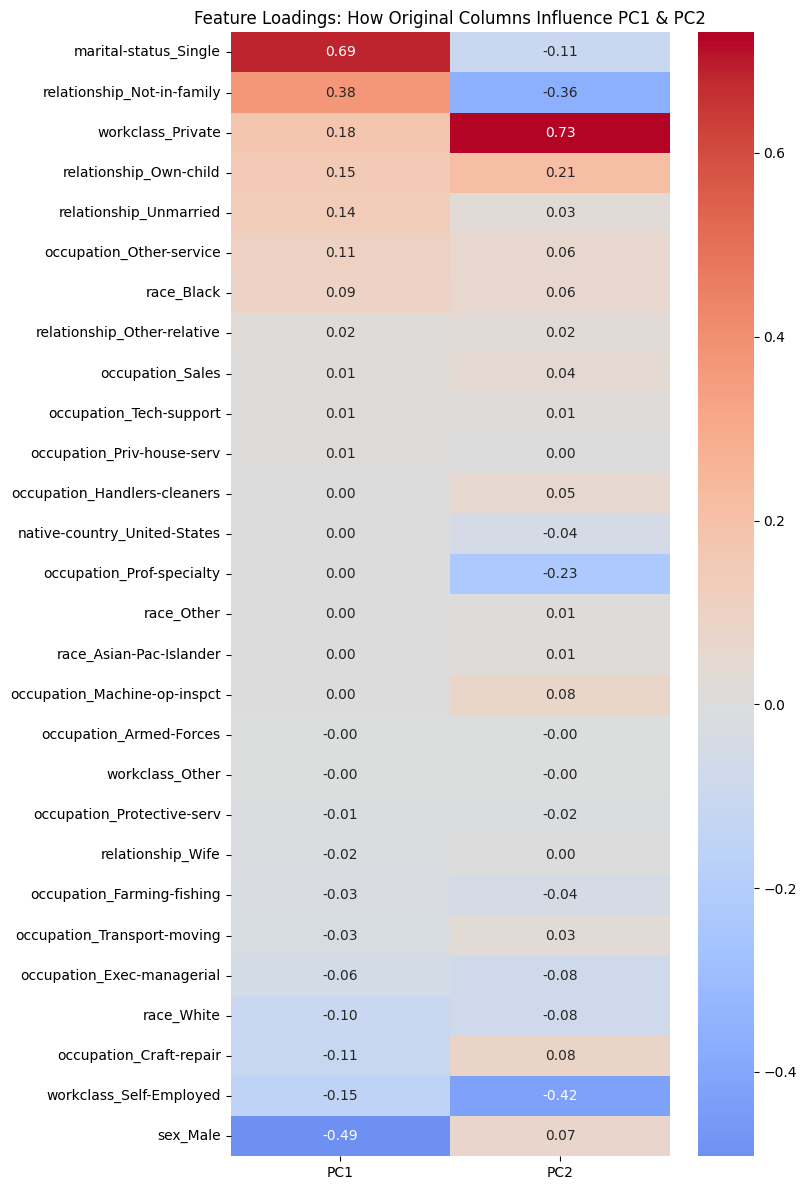

In [ ]:
# ---------------------------------------------------------
# Step 1: Fit PCA on all components to analyze variance
# ---------------------------------------------------------
# We use all 28 components initially to see the full picture
pca_full = PCA(n_components=data.shape[1])
pca_full.fit(data)

# Calculate cumulative variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# --- GRAPH 1: Scree Plot (Explained Variance) ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, 29), cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.90, color='r', linestyle='-', label='90% Variance Threshold')
plt.axhline(y=0.95, color='g', linestyle='-', label='95% Variance Threshold')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.xticks(range(1, 29))
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Step 2: Apply PCA with your chosen threshold (e.g., 95%)
# ---------------------------------------------------------
# Let's assume you want to keep 95% of the information
pca_final = PCA(n_components=0.95)
pca_features = pca_final.fit_transform(data)

# Create the new DataFrame with the Principal Components
pca_columns = [f"PC{i+1}" for i in range(pca_features.shape[1])]
pca_df = pd.DataFrame(data=pca_features, columns=pca_columns, index=data.index)

print(f"Original feature count: 28")
print(f"Reduced feature count (95% variance): {pca_final.n_components_}")
print("\nFirst 5 rows of the PCA DataFrame:")
print(pca_df.head())

# ---------------------------------------------------------
# Step 3: Visualizing the Data in 2D (PC1 vs PC2)
# ---------------------------------------------------------
# --- GRAPH 2: 2D Scatter Plot ---
plt.figure(figsize=(10, 8))
# We plot the first two principal components
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.3, c='teal', edgecolors='none')
plt.title('Data Projected onto First 2 Principal Components (PC1 vs PC2)')
plt.xlabel(f'Principal Component 1 ({pca_final.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca_final.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Step 4: Understanding the Components (Feature Loadings)
# ---------------------------------------------------------
# This helps us see which of your original 28 columns contribute most to PC1 and PC2
loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=pca_columns,
    index=data.columns
)

# --- GRAPH 3: Feature Loadings Heatmap for PC1 and PC2 ---
plt.figure(figsize=(8, 12))
sns.heatmap(loadings[['PC1', 'PC2']].sort_values(by='PC1', ascending=False),
            annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Loadings: How Original Columns Influence PC1 & PC2')
plt.tight_layout()
plt.show()

# Clustering

## K-means

In [ ]:
# list to store WCSS value for each value of K
wcss = []
# find WCSS value for each K
for i in range(1, 11):
  # initialization
  k_means_model = KMeans(n_clusters=i, n_init=5)
  # model building
  k_means_model.fit(data)
  wcss_value = k_means_model.inertia_ # value of WCSS for k = i
  wcss.append(wcss_value)

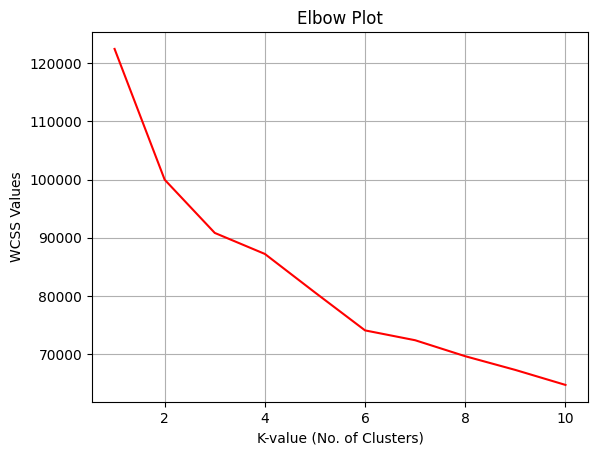

In [ ]:
# elbow plt(k vs wcss)
plt.plot(range(1, 11), wcss, c='r')
plt.xlabel('K-value (No. of Clusters)')
plt.ylabel('WCSS Values')
plt.title("Elbow Plot")
plt.grid()
plt.show()

In [ ]:
# optimum no. of clusters = 6
# inference from the Elbow Plot

# now create a K-means model with 6 clusters
# initialize model
k_means = KMeans(n_clusters=6, n_init=5)
# model building
k_means.fit(data)
# model prediction
cluster_label = k_means.predict(data)
cluster_label

array([2, 3, 1, ..., 0, 5, 3], dtype=int32)

In [ ]:
# After updating the DataFrame with the cluster information
data['Cluster'] = cluster_label
data.head(3)

,workclass_Other,workclass_Private,workclass_Self-Employed,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,occupation_Armed-Forces,...,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male,native-country_United-States,Cluster
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,1,1,2
1,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,3
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,1


### Evaluating Cluster Quality
We will calculate the Silhouette Score and visualize the clusters in 2D using PCA.

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1. Silhouette Score (Sampling for performance if dataset is large)
sample_size = 10000
score = silhouette_score(data.drop('Cluster', axis=1), cluster_label, sample_size=sample_size, random_state=42)
print(f"Silhouette Score (sampled {sample_size}): {score:.4f}")

Silhouette Score (sampled 10000): 0.1873


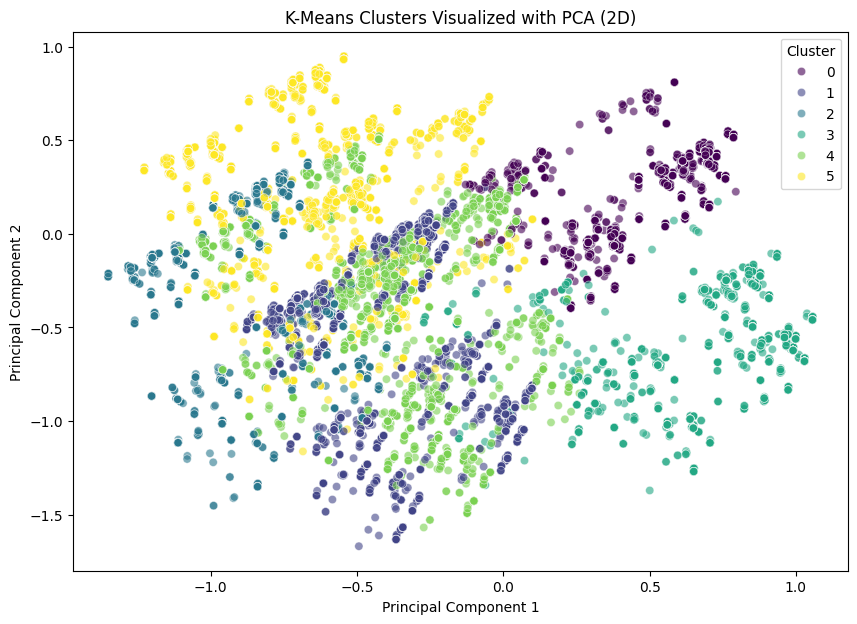

In [ ]:
# 2. PCA Visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data.drop('Cluster', axis=1))

plt.figure(figsize=(10, 7))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=cluster_label, palette='viridis', alpha=0.6)
plt.title('K-Means Clusters Visualized with PCA (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()